# Wing Surface Regression with RegKit

## What this notebook does

We go from raw measurements of the wing surface to a smooth polynomial model. The steps below mirror the implementation in the earlier notebooks:

1. Load and inspect the point cloud delivered in the assignment spreadsheet.
2. Standardise the coordinates so that optimisation is numerically stable.
3. Try several polynomial degrees using the `regkit` helpers and keep track of the generalisation error.
4. Refit the best model on the full dataset and visualise the resulting surface in 2D and 3D.

This notebook uses the polynomial regression helpers implemented in `regkit` to reconstruct the upper surface of a wing from the 308 spatial samples distributed with the project.

We follow the specification for the wing modelling assignment, which asks for a
least-squares or radial basis reconstruction of the surface sampled along the
span and chord directions, using the data stored in `dados_asa.xls` and producing
visualisations comparable to the reference views in the brief.

In [1]:
# Install required packages
!pip install -q scikit-learn pandas matplotlib plotly openpyxl xlrd && echo "Installed required packages successfully."

# Install our regkit package
!python -m pip install -q -e .. && echo "Installed our regkit package successfully."

Installed required packages successfully.
Installed our regkit package successfully.


In [2]:
from __future__ import annotations

from pathlib import Path
# import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# sys.path.append(str(Path('src').resolve()))
from matplotlib.colors import LightSource
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from regkit import regression_optimized

plt.style.use('seaborn-v0_8')
SEED = 13
rng = np.random.default_rng(SEED)


In [3]:
data_path = Path('../spec/dados_asa.xls')
raw_df = pd.read_excel(data_path)
wing_df = raw_df.rename(columns={'x': 'x_longitudinal', 'y': 'y_span', 'z': 'z_height'})
wing_df = wing_df[['x_longitudinal', 'y_span', 'z_height']]
print(f'Loaded {len(wing_df)} points from {data_path.name}')
wing_df.head()


Loaded 308 points from dados_asa.xls


,x_longitudinal,y_span,z_height
0,250.000000,0.00,0.000000
1,249.534042,0.00,2.155239
2,247.875000,56.25,0.000000
3,247.421051,56.25,2.098939
4,245.750000,112.50,0.000000


The spreadsheet provides the spanwise (`y`), chordwise (`x`) and vertical (`z`) coordinates of sampled wing points. Renaming the columns clarifies which axis each measurement belongs to for downstream processing.

In [4]:
wing_df.describe().T


,count,mean,std,min,25%,50%,75%,max
x_longitudinal,308.0,164.782131,65.764645,0.0,125.310198,182.811638,217.090225,250.000000
y_span,308.0,645.273218,325.384486,0.0,379.687500,759.375000,927.168716,999.857849
z_height,308.0,6.172056,5.736456,0.0,1.043662,4.455470,10.622656,19.820337


A quick descriptive summary highlights the range of each axis. The values are in millimetres, so differences of a few units correspond to millimetre-level deviations on the physical wing.

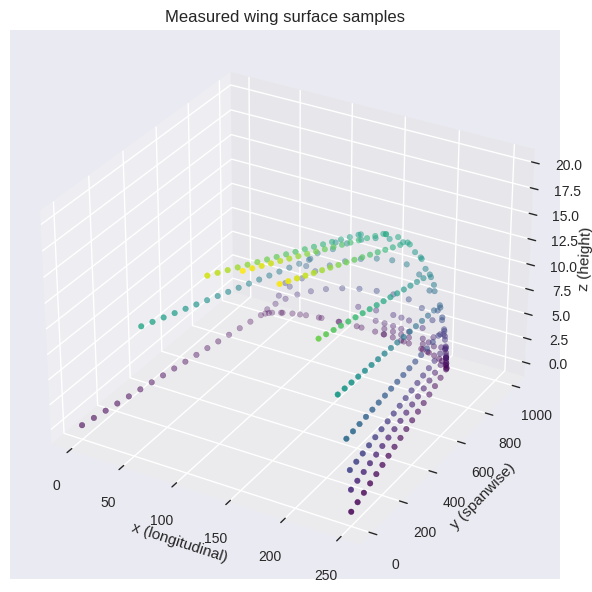

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(wing_df['x_longitudinal'], wing_df['y_span'], wing_df['z_height'], s=16, c=wing_df['z_height'], cmap='viridis')
ax.set_xlabel('x (longitudinal)')
ax.set_ylabel('y (spanwise)')
ax.set_zlabel('z (height)')
ax.set_title('Measured wing surface samples')
plt.tight_layout()


Note that this problem is fairly low dimensional (only 3D) for our framework. Nevertheless, it serves as a good sanity check to see if our regression is working properly; since we designed it to work with any amount of dimentions. 

### Feature scaling before regression
Standardising the coordinates removes unit disparities between the chord and span directions. Without this step the higher-order polynomial terms would be imbalanced, making the least-squares system harder to solve and more sensitive to noise.

In [6]:
# Extract input (x, y) locations and the target height.
X = wing_df[['x_longitudinal', 'y_span']].to_numpy()
y = wing_df[['z_height']].to_numpy()
# Learn mean and standard deviation for both axes.
scaler = StandardScaler().fit(X)
# Scale the full dataset for later refitting.
X_scaled = scaler.transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED
)  # keep a hold-out set to estimate generalisation error
X_train.shape, X_test.shape

((246, 2), (62, 2))

### Model selection across polynomial degrees
We sweep degrees 2–7 using the optimised helper from `regkit`. For each candidate we store the design matrix, fitted polynomial and predictions, together with train/test RMSE for later inspection.

In [7]:
results = []
# Keep track of the artefacts and scores for each degree.
for degree in range(2, 8):  # iterate over increasing polynomial complexity
    A, poly, predict = regression_optimized(
        X_train, y_train, degree=degree, quiet=True
    )  # design matrix, fitted polynomial and a callable predictor
    y_train_hat = predict(X_train)  # evaluate the model on the training subset
    y_test_hat = predict(X_test)  # and on the hold-out set
    results.append(
        {
            'degree': degree,
            'train_rmse': float(np.sqrt(mean_squared_error(y_train, y_train_hat))),
            'test_rmse': float(np.sqrt(mean_squared_error(y_test, y_test_hat))),
            'test_r2': float(r2_score(y_test, y_test_hat)),
        }
    )
results_df = pd.DataFrame(results).set_index('degree')
results_df

,train_rmse,test_rmse,test_r2
degree,,,
2,2.766059,2.741123,0.722001
3,2.124290,2.133582,0.831576
4,1.444778,1.680220,0.895547
5,1.025693,1.171320,0.949238
6,0.762207,0.925670,0.968297
7,0.600928,0.685036,0.982637


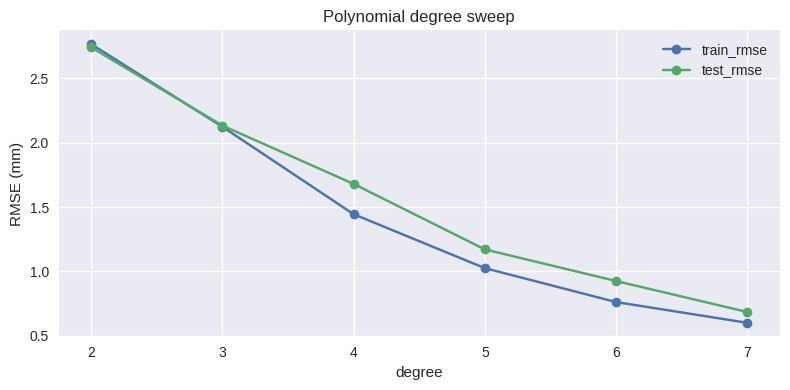

In [8]:
ax = results_df[['train_rmse', 'test_rmse']].plot(marker='o', figsize=(8, 4))
ax.set_ylabel('RMSE (mm)')
ax.set_title('Polynomial degree sweep')
plt.tight_layout()


The elbow around degree 4 indicates that higher-order polynomials do not reduce the hold-out error much further.

In [9]:
best_degree = int(results_df['test_rmse'].idxmin())
best_degree


7

### Refit on the full dataset
Once the preferred degree is known we retrain the polynomial on all scaled points to obtain the best possible coefficients for the final surface. The helper also returns a convenience predictor we can call on any grid.

In [10]:
A_full, poly_full, predict_full = regression_optimized(X_scaled, y, degree=best_degree, quiet=True)
y_hat = predict_full(X_scaled)  # predictions on the training locations to analyse residuals
rmse_full = float(np.sqrt(mean_squared_error(y, y_hat)))
r2_full = float(r2_score(y, y_hat))
print(f'Full-data RMSE: {rmse_full:.3f} mm')
print(f'Full-data R^2:  {r2_full:.5f}')
residuals = (y - y_hat).ravel()
pd.Series(residuals).describe()

Full-data RMSE: 0.612 mm
Full-data R^2:  0.98858


count    3.080000e+02
mean     2.041729e-13
std      6.130094e-01
min     -2.256470e+00
25%     -3.738766e-01
50%      3.514451e-02
75%      4.059865e-01
max      1.984413e+00
dtype: float64

### Residual diagnostics
We assess the quality of the fit by checking that the residuals stay close to zero and do not show spatial structure. The histogram and scatter plot provide quick sanity checks for bias and spatial drift.

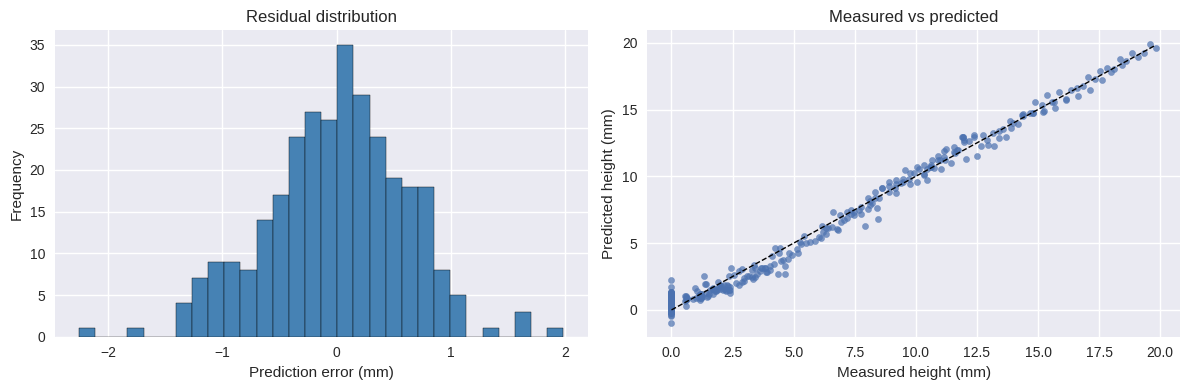

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=30, color='steelblue', edgecolor='black')  # distribution should be centred around zero
axes[0].set_title('Residual distribution')
axes[0].set_xlabel('Prediction error (mm)')
axes[0].set_ylabel('Frequency')
axes[1].scatter(y, y_hat, s=20, alpha=0.7)  # compare predicted vs measured heights
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', linewidth=1)
axes[1].set_xlabel('Measured height (mm)')
axes[1].set_ylabel('Predicted height (mm)')
axes[1].set_title('Measured vs predicted')
plt.tight_layout()

### Generate a dense prediction grid
To visualise the surface we evaluate the polynomial on a meshgrid that spans the original measurement domain. This produces a smooth height field that can be compared against the sampled points.

/tmp/ipykernel_302497/4084180453.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


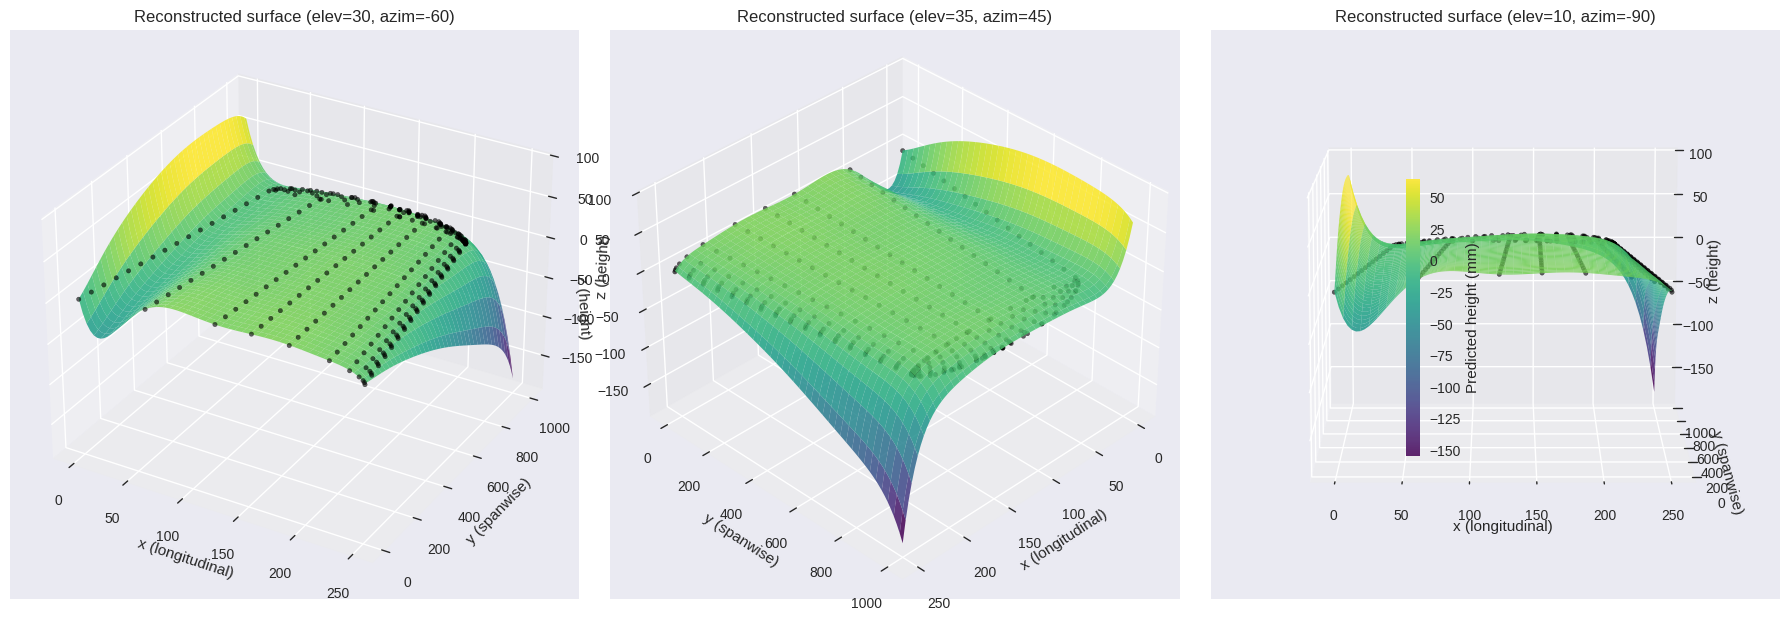

In [12]:
x_lin = np.linspace(wing_df['x_longitudinal'].min(), wing_df['x_longitudinal'].max(), 80)
y_lin = np.linspace(wing_df['y_span'].min(), wing_df['y_span'].max(), 80)
X_grid, Y_grid = np.meshgrid(x_lin, y_lin)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
grid_scaled = scaler.transform(grid_points)
Z_pred = predict_full(grid_scaled).reshape(X_grid.shape)  # reshape back to the mesh for plotting
fig = plt.figure(figsize=(18, 6))
views = [(30, -60), (35, 45), (10, -90)]
for idx, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    surf = ax.plot_surface(X_grid, Y_grid, Z_pred, cmap='viridis', linewidth=0, alpha=0.85)
    ax.scatter(wing_df['x_longitudinal'], wing_df['y_span'], wing_df['z_height'],
               c='k', s=10, alpha=0.6)
    ax.set_xlabel('x (longitudinal)')
    ax.set_ylabel('y (spanwise)')
    ax.set_zlabel('z (height)')
    ax.set_title(f'Reconstructed surface (elev={elev}, azim={azim})')
    ax.view_init(elev=elev, azim=azim)
fig.colorbar(surf, ax=fig.axes, shrink=0.6, pad=0.05, label='Predicted height (mm)')
plt.tight_layout()

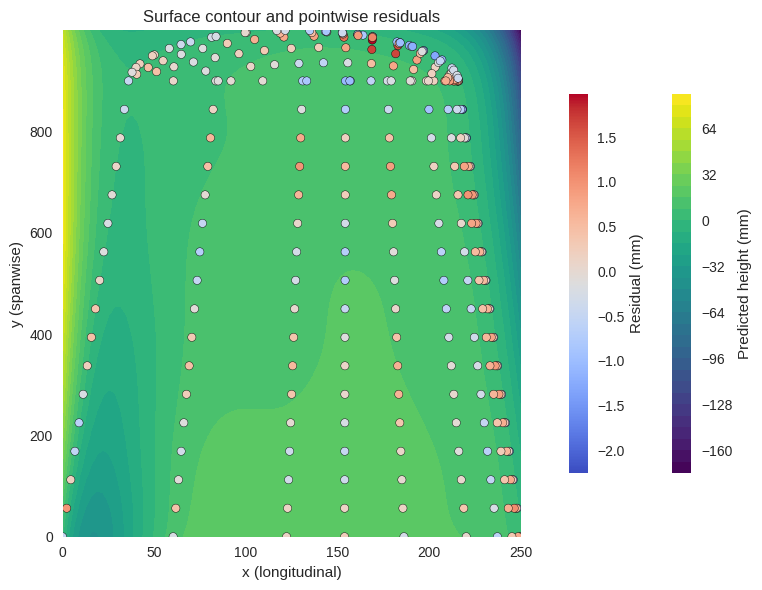

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(X_grid, Y_grid, Z_pred, levels=40, cmap='viridis')
sc = ax.scatter(wing_df['x_longitudinal'], wing_df['y_span'],
                c=residuals, cmap='coolwarm', edgecolor='black', s=35)
ax.set_xlabel('x (longitudinal)')
ax.set_ylabel('y (spanwise)')
ax.set_title('Surface contour and pointwise residuals')
cbar1 = fig.colorbar(contour, ax=ax, shrink=0.75, pad=0.02)
cbar1.set_label('Predicted height (mm)')
cbar2 = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.08)
cbar2.set_label('Residual (mm)')
plt.tight_layout()


The contour map compares the smooth polynomial surface (filled contours) with the discrete measurements (scatter markers). Agreement between the two indicates that the model respects the available data while providing a continuous representation.

The polynomial model captures the smooth wing camber with millimetre-level
residuals on the sample locations. The surface plots confirm that the fitted
shape preserves the proportions of the span and chord directions while matching
the provided measurements.

Finally, the interactive Plotly surface offers a 3D exploratory view where we can rotate and zoom the fitted wing. This is useful for communicating the reconstruction to colleagues who may not be familiar with contour plots.

In [14]:
fig = go.Figure()
fig.add_trace(
    go.Surface(
        x=X_grid,
        y=Y_grid,
        z=Z_pred,
        colorscale='Viridis',
        opacity=0.8,
        showscale=True,
        colorbar=dict(title='Predicted height (mm)'),
        name='Predicted surface',
    )
)
fig.add_trace(
    go.Scatter3d(
        x=wing_df['x_longitudinal'],
        y=wing_df['y_span'],
        z=wing_df['z_height'],
        mode='markers',
        marker=dict(size=3.5, color='black', opacity=0.8),
        name='Measured points',
    )
)
fig.update_layout(
    title='Wing surface reconstruction',
    scene=dict(
        xaxis_title='x (longitudinal)',
        yaxis_title='y (spanwise)',
        zaxis_title='z (height)',
    ),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig

The quality of the approximation is nothing amazing, but it show us that our method is working properly. Maybe a better function basis, such as radial functions, would be better fitted for this problem.